# Time statistics

Global ensemble diagnostics across all regimes. Land-seed filter count
and final displacement distribution.

In [1]:
import dask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import xarray as xr

# Parameters

In [2]:
output_root = "../output"

# Dask cluster

Connect to an external scheduler when ``SCHEDULER_FILE`` is set (written
by the multi-task SLURM job). Otherwise spin up a local cluster on the
current node.

In [3]:
import os
import time
from dask.distributed import Client

scheduler_file = os.environ.get("SCHEDULER_FILE")
if scheduler_file:
    for _ in range(60):
        if os.path.exists(scheduler_file):
            break
        time.sleep(1)
    client = Client(scheduler_file=scheduler_file)
else:
    client = Client(ip="0.0.0.0")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://192.168.178.47:8787/status,
Dashboard: http://192.168.178.47:8787/status,Workers: 4
Total threads: 12,Total memory: 36.00 GiB
Status: running,Using processes: True
Comm: tcp://192.168.178.47:60104,Workers: 0
Dashboard: http://192.168.178.47:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://192.168.178.47:60116,Total threads: 3
Dashboard: http://192.168.178.47:60120/status,Memory: 9.00 GiB
Nanny: tcp://192.168.178.47:60107,


# Load all regimes

In [4]:
output_root = Path(output_root)
trajectory_root = output_root / "Trajectories"
regimes = sorted(p.name for p in trajectory_root.iterdir() if p.is_dir())
print(f"Regimes: {regimes}")

Regimes: ['bottom', 'surface', 'surface_stokes']


In [5]:
regime_datasets = {}
land_seeded_masks = {}
for regime in regimes:
    zarr_files = sorted((trajectory_root / regime).glob("**/*.zarr"))
    ds_raw = xr.concat([xr.open_zarr(z) for z in zarr_files], dim="trajectory")
    # Trajectories whose first step has zero displacement were seeded on
    # land and never advected; mask them across all obs.
    land_seeded = (
        (ds_raw.lon.diff("obs").isel(obs=0, drop=True) == 0)
        & (ds_raw.lat.diff("obs").isel(obs=0, drop=True) == 0)
    )
    ds_masked = ds_raw.where(~land_seeded)
    regime_datasets[regime] = ds_masked
    land_seeded_masks[regime] = land_seeded
regime_datasets

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_89769/513354048.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'obs' ('obs',) The recommendation is to set join explicitly for this case.
  ds_raw = xr.concat([xr.open_zarr(z) for z in zarr_files], dim="trajectory")


{'bottom': <xarray.Dataset> Size: 22GB
 Dimensions:          (trajectory: 87200, obs: 5274)
 Coordinates:
   * trajectory       (trajectory) int64 698kB 0 1 2 3 ... 87197 87198 87199
   * obs              (obs) int32 21kB 0 1 2 3 4 5 ... 5269 5270 5271 5272 5273
 Data variables:
     age_sec          (trajectory, obs) float32 2GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
     cell_ID          (trajectory, obs) float32 2GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
     lat              (trajectory, obs) float64 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
     lon              (trajectory, obs) float64 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
     max_age_sec      (trajectory, obs) float32 2GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
     time             (trajectory, obs) datetime64[ns] 4GB dask.array<chunksize=(10000, 1000), meta=np.ndarray>
     velocity_factor  (trajectory, obs) float32 2GB dask.array<chunksize=(10000, 10

# Compute per-regime diagnostics (one shared pass per regime)

For each regime, land-seed count and first/last coords walk the same
trajectory graph; `dask.compute(*)` evaluates them in one go.

Last valid obs uses `ffill("obs")` + `isel(obs=-1)` to tolerate any
NaN-tail inside a chunk (trajectories that die before their chunk ends).

In [6]:
per_regime = {}
for regime, ds in regime_datasets.items():
    n_total = ds.sizes["trajectory"]
    lazy = dict(
        land_count=land_seeded_masks[regime].sum(),
        first_lon=ds.lon.isel(obs=0, drop=True),
        first_lat=ds.lat.isel(obs=0, drop=True),
        last_lon=ds.lon.ffill("obs").isel(obs=-1, drop=True),
        last_lat=ds.lat.ffill("obs").isel(obs=-1, drop=True),
    )
    results = dict(zip(lazy.keys(), dask.compute(*lazy.values())))
    land = int(results["land_count"])
    results["n_total"] = n_total
    results["n_valid"] = n_total - land
    per_regime[regime] = results
    print(
        f"{regime}: {n_total} trajectories, {land} land-seeded "
        f"({results['n_valid']} valid)"
    )

bottom: 87200 trajectories, 30425 land-seeded (56775 valid)


surface: 174400 trajectories, 60704 land-seeded (113696 valid)


surface_stokes: 87200 trajectories, 29881 land-seeded (57319 valid)


# Land-seed count per regime

<Axes: >

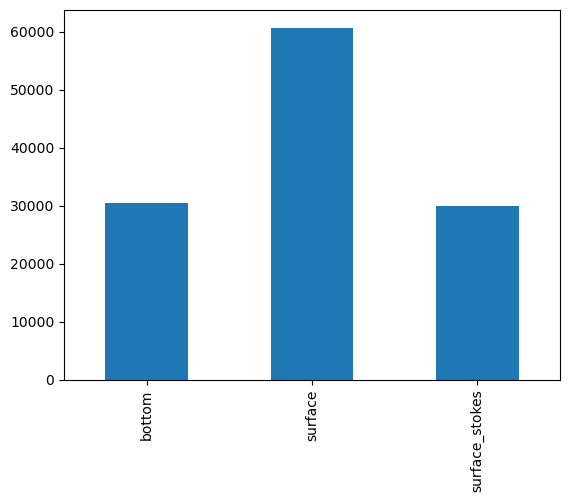

In [7]:
land_seed = pd.Series(
    {r: int(per_regime[r]["n_total"] - per_regime[r]["n_valid"]) for r in regimes},
    name="land_seeded",
)
land_seed.plot.bar()

# Final displacement distribution

Great-circle approximation (111 km per degree lat). NaN last-lon (land-
seeded) drops out of the histogram automatically. `histtype="step"` so
the three regimes overlay without bar occlusion.

Text(0.5, 0, 'Final displacement (km)')

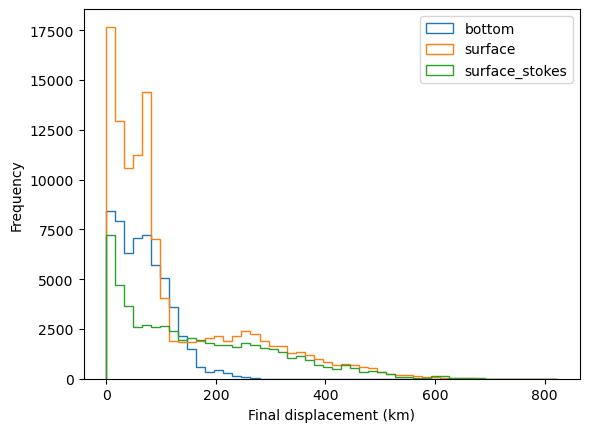

In [8]:
finals = {}
for regime in regimes:
    r = per_regime[regime]
    dlat = r["last_lat"] - r["first_lat"]
    dlon = (r["last_lon"] - r["first_lon"]) * np.cos(np.deg2rad(r["first_lat"]))
    finals[regime] = (111.0 * np.sqrt(dlat ** 2 + dlon ** 2)).values

df_final = pd.DataFrame({r: pd.Series(v) for r, v in finals.items()}).dropna(how="all")
ax = df_final.plot.hist(bins=50, histtype="step")
ax.set_xlabel("Final displacement (km)")